Dataset Preview
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  


c:\Users\Prajjwal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Prajjwal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Prajjwal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Prajjwal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory le

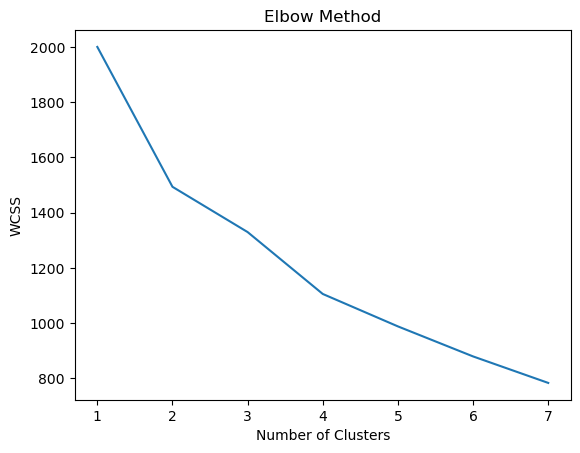


Segments created using K-Means
Hierarchical clustering completed
DBSCAN clustering completed


c:\Users\Prajjwal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


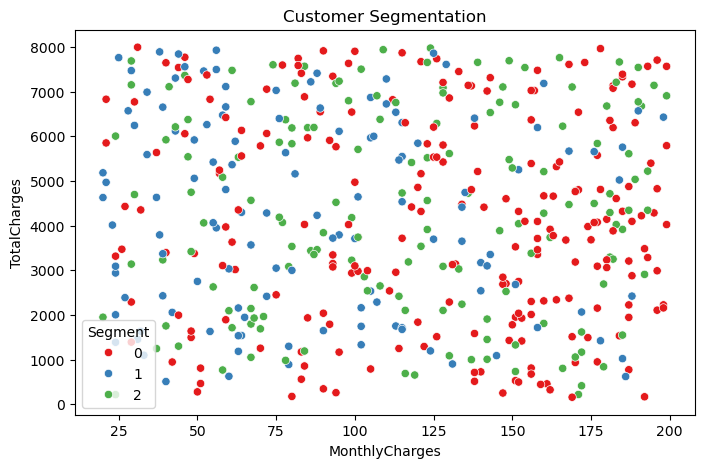

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
# ---------------------------------------------
# Week 11: Customer Segmentation & Prediction
# Using customer_churn.csv
# ---------------------------------------------

import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------
# Load Dataset
# ---------------------------------------------

df = pd.read_csv("customer_churn.csv")

print("Dataset Preview")
print(df.head())

# ---------------------------------------------
# Encode Categorical Columns
# ---------------------------------------------

le = LabelEncoder()

df["Contract"] = le.fit_transform(df["Contract"])
df["PaymentMethod"] = le.fit_transform(df["PaymentMethod"])
df["PaperlessBilling"] = le.fit_transform(df["PaperlessBilling"])

# ---------------------------------------------
# Select Features for Clustering
# ---------------------------------------------

features = df[['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen']]

scaler = StandardScaler()
X = scaler.fit_transform(features)

# ---------------------------------------------
# Elbow Method
# ---------------------------------------------

wcss = []

for i in range(1,8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,8), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ---------------------------------------------
# K-Means Clustering
# ---------------------------------------------

kmeans = KMeans(n_clusters=3, random_state=42)
df["Segment"] = kmeans.fit_predict(X)

print("\nSegments created using K-Means")

# ---------------------------------------------
# Hierarchical Clustering
# ---------------------------------------------

hc = AgglomerativeClustering(n_clusters=3)
df["HC_Segment"] = hc.fit_predict(X)

print("Hierarchical clustering completed")

# ---------------------------------------------
# DBSCAN Clustering
# ---------------------------------------------

dbscan = DBSCAN(eps=0.8, min_samples=5)
df["DBSCAN_Segment"] = dbscan.fit_predict(X)

print("DBSCAN clustering completed")

# ---------------------------------------------
# Visualize Segments
# ---------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Segment",
    palette="Set1"
)

plt.title("Customer Segmentation")
plt.show()

# ---------------------------------------------
# Segment Analysis
# ---------------------------------------------

segment_summary = df.groupby("Segment").mean(numeric_only=True)

print("\nSegment Characteristics")
print(segment_summary)

# ---------------------------------------------
# Build Random Forest Model for Each Segment
# ---------------------------------------------

results = []

for seg in df["Segment"].unique():

    segment_data = df[df["Segment"] == seg]

    if len(segment_data) < 10:
        continue

    X_seg = segment_data[['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen']]
    y_seg = segment_data['Churn']

    X_train,X_test,y_train,y_test = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(random_state=42)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)
    prec = precision_score(y_test,pred, zero_division=0)
    rec = recall_score(y_test,pred, zero_division=0)
    f1 = f1_score(y_test,pred, zero_division=0)

    results.append({
        "Segment":seg,
        "Accuracy":acc,
        "Precision":prec,
        "Recall":rec,
        "F1":f1
    })

# ---------------------------------------------
# Hyperparameter Tuning
# ---------------------------------------------

param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5,10]
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid,
                    cv=3)

grid.fit(X_train,y_train)

print("\nBest Parameters:", grid.best_params_)

# ---------------------------------------------
# Save Results
# ---------------------------------------------

results_df = pd.DataFrame(results)

print("\nModel Performance per Segment")
print(results_df)

results_df.to_csv("model_evaluation_results.csv",index=False)

print("\nResults saved to model_evaluation_results.csv")

# ---------------------------------------------
# Business Insights
# ---------------------------------------------

print("\nCUSTOMER SEGMENT PERFORMANCE")

for r in results:
    print(f"Segment {r['Segment']} -> Accuracy: {round(r['Accuracy'],2)}, F1: {round(r['F1'],2)}")

print("\nCustomer segmentation and prediction pipeline completed successfully.")